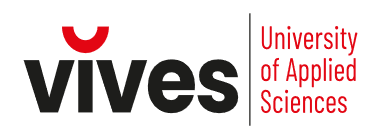<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **LINEAR REGRESSION: THEORY**

In this notebook we discuss **linear regression**, focusing mainly on simple linear regression with 2 variables. In addition to finding the exact solution with the least squares method, we also show how to apply **Gradient Descent** to find an approximate solution.

The Gradient Descent algorithm is also used in training other machine learning models, and is therefore discussed several times later in the course. It is even applied to artificial neural networks, and is therefore also an important topic in the field of Deep Learning.

But in order to properly understand the Gradient Descent algorithm, we first need to understand what a gradient is in mathematics.

## **1. Gradient of a function**

### What is a gradient?

A **gradient** shows how a certain quantity changes as a function of another quantity. For example, consider a color gradient that shows the progression of a color as a function of location, such as the figure below shows the continuous transition from magenta to yellow:

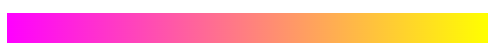

Speed ​​is another example, because it expresses the progression of the number of kilometers traveled as a function of time. That is why the unit of speed is kilometers per hour.

Below you can see an example. The graph shows the distance traveled in km versus the time in hours that was needed to travel that distance:

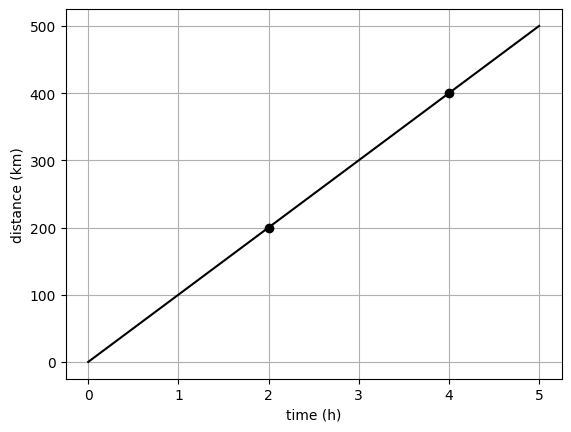

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100 # will make the figures a bit bigger

distances = np.arange(0, 600, 100) # range of distances from 0 to 500km with steps of 100km
times = np.arange(0, 6, 1) # range of times from 0 to 5h with steps of 1h

plt.plot(times, distances, 'k-');
plt.plot([2, 4], [200, 400], 'ko'); # 2 points on the line
plt.xlabel("time (h)");
plt.ylabel("distance (km)");
plt.grid();

We can now calculate the speed using the graph. First, we read off two random points, e.g. (2, 200) and (4, 400). These points are indicated by black dots in the above graph. Using these two points, we can now calculate the speed as follows:

> $speed = \frac{distance_2 - distance_1}{time_2 - time_1}$

When we fill in the coordinates of the 2 points, we get:

> $speed = \frac{400 km - 200 km}{4h - 2h} = 100 km/h$

We could also have just taken 1 point, e.g., 400 / 4, because the line passes through the origin. In this case, the 2nd point is (0, 0), because after 0 hours we have indeed traveled 0 km. Also note that the speed is constant, which is why we can apply this formula with 2 random points on the line. But we are not allowed to do that if the relationship between distance and time cannot be represented by a straight line!

### Linear relationship

In mathematics, the gradient indicates the direction in which a **function** varies the most and how large that variation is. When it concerns a function in two dimensions, we call that gradient the **derivative**. The simplest example of a 2D function is a line, and in that case the derivative is the **slope**, abbreviated rico. In our example, we also get a line when we plot the distance as a function of time. We say that the relationship between distance and time is **linear**.

The general equation of a **line** is:

> $y = ax + b$

We call $y$ the **dependent variable**, $x$ the **independent variable**, $a$ the **slope** and $b$ the **intercept**, i.e. the intersection of the line with the y-axis. In our example, $y$ is the distance, $x$ the time, $a$ the velocity, and $b$ the initial distance, which is zero here. So we get the following equation:

> $y = 100 x$

This equation is a function $y$ with variable $x$. So it expresses a relationship between variables $x$ and $y$. Because there is only 1 independent variable, we can represent the function in a two-dimensional (x,y) coordinate system. In our example, the function expresses the linear relationship between time and distance. We also say that distance is a function of time. We write this as $y(x)$.

We can also use other symbols for the variables, and in physics, distance is often represented by $x$, time by $t$, and velocity by $v$. We then get:

> $x = v t$

This is of course a bit confusing, because here the dependent variable $y$ is distance $x$, and the independent variable $x$ is time $t$. Incidentally, the slope $a$ is velocity $v$.

The **derivative** of $y$ with respect to $x$ is written as:

> $y'(x) = \frac{dy}{dx}$

In our example, this is the derivative of the distance with respect to time, which is the velocity. In the case of a line, this derivative is simply the slope:

> $\frac{dy}{dx} = a$

Or using the symbols from physics:

> $\frac{dx}{dt} = v$

It expresses how much $y$ changes when $x$ increases by one unit. In our example, the derivative expresses how much distance is added when we are 1 h further. Physically, this is the velocity. Graphically, the slope is the slope of the line: if the slope is positive, the line rises; if the slope is negative, the line falls; if the slope is 0, the line is horizontal. The size of the slope also indicates how much the line rises or falls.

You can effectively see $dy$ and $dx$ as differences, even though they are infinitely small differences in one point. In the case of a line, these differences are the same in all points, so the derivative is constant, and therefore we can write:

> $\frac{dy}{dx} = \frac{\Delta y}{\Delta x} = \frac{y_2-y_1}{x_2-x_1}$

where we take two random points $(x_1, y_1)$ and $(x_2, y_2)$ on the line. That is exactly how we calculated the speed above. This is also shown graphically in the figure.

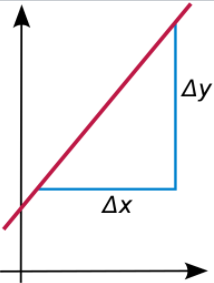

### Non-linear relationship

Of course, it gets a bit more difficult if our relationship between variables $x$ and $y$ is not linear. Then we get a curve instead of a straight line. Let's return to our velocity example, but suppose that this time we start slowly, and then accelerate steadily, as in the graph below:

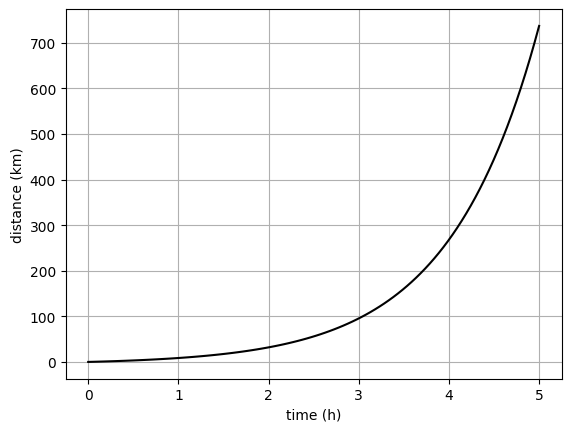

In [ ]:
times = np.linspace(0, 5, 100)     # series of 100 times from 0 to 5h
distances = 5 * np.exp(times) - 5  # exponential increase of distance as a function of time

plt.plot(times, distances, 'k-');
plt.xlabel("time (h)");
plt.ylabel("distance (km)");
plt.grid();

What is the speed after 2 hours of driving? Fortunately, in this example we know the relationship between distance $y$ and speed $x$:

> $y = 5e^x - 5$

Or using the symbols from physics:

> $x = 5e^t - 5$

Symbol $e$ stands for Euler's constant, but in Python we can easily use the NumPy function `exp`.

To know the speed, we need to take the derivative of the distance with respect to time:

> $\frac{dy}{dx} = 5e^x$

Or using the symbols from physics:

> $\frac{dx}{dt} = 5e^t$

The derivative, in this case the speed, is no longer constant, but also a function of time. Now we can calculate that after 2 hours of driving the speed is $5e^2$ km/h:

In [ ]:
print(f"The speed after 2 hours of driving is {5 * np.exp(2) :.2f} km/h")

The speed after 2 hours of driving is 36.95 km/h


So the speed is no longer constant, and after 4 hours of driving the speed is indeed much higher:

In [ ]:
print(f"The speed after 2 hours of driving is {5 * np.exp(4) :.2f} km/h")

The speed after 2 hours of driving is 272.99 km/h


For a curve, the derivative at a point on that curve is the slope of the **tangent** to the curve at that point. That tangent is a straight line and can therefore also be expressed using the equation of a straight line. Because we know 1 point, namely the point on the curve, and the slope, namely the derivative at that point, we can easily write down the equation of the tangent:

> $y = y_1 + \frac{dy_1}{dx_1}(x-x_1)$

where $(x_1, y_1)$ is the point on the curve. Let's now plot that for the 2 points that correspond to 2 hours and 4 hours of driving:

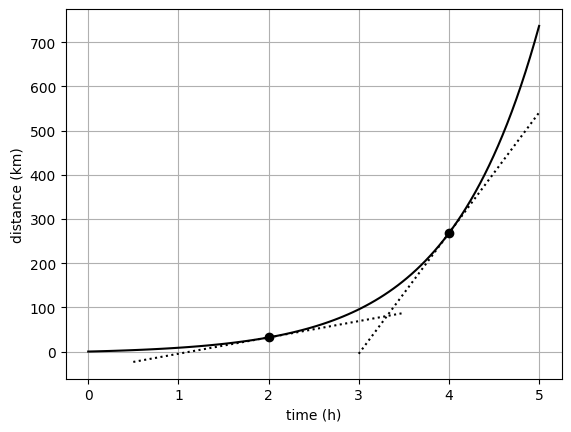

In [ ]:
# data
y = lambda x: 5 * np.exp(x) - 5      # distance as a function of time
dydx = lambda x: 5 * np.exp(x)       # velocity as a function of time (= derivative of distance with respect to time)
x1, x2 = 2, 4                        # we take the 2 points corresponding to 2h and 4h
y1, y2 = y(x1), y(x2)                # the distance for those 2 points
dy1dx1, dy2dx2 = dydx(x1), dydx(x2)  # the velocity for those 2 points

# comparison tangent with xlim the 2 x-coordinates of the ends of the tangent
tangent = lambda xlim, xpoint, ypoint, rico: ypoint + rico * (xlim - xpoint)

# plot of the curve with the 2 points on it
plt.plot(times, distances, 'k-');
plt.plot([x1, x2], [y1, y2], 'ko');

# tangent at first point
xlim1 = np.array([0.5, 3.5])
plt.plot(xlim1, tangent(xlim1, x1, y1, dy1dx1), 'k:')
# tangent at second point
xlim2 = np.array([3, 5])
plt.plot(xlim2, tangent(xlim2, x2, y2, dy2dx2), 'k:')

# labels and grid
plt.xlabel("time (h)");
plt.ylabel("distance (km)");
plt.grid();

So we see indeed that the derivative at a point on the curve is equal to the slope of the tangent to that curve at that point. That is, the derivative not only indicates whether the curve at that point is rising (if the derivative is greater than 0), falling (if the derivative is less than 0), or horizontal (if the derivative is equal to 0), but also how much the curve is rising or falling at that point.

We can extend this way of reasoning to more than 2 dimensions. In that case we speak of the **gradient**. Suppose you have a 2D surface in a 3D coordinate system. In that case there are 2 independent variables, and the surface represents the dependent variable, which is a function of those 2 independent variables. We now have to take the partial derivatives of that function with respect to each of those 2 independent variables. Those 2 partial derivatives together are called the gradient, and they indicate how much and in which direction the curve rises or falls the most at a certain point. In 3D we can represent this as a tangent plane to the surface at a given point instead of a tangent line, as can be seen in the figure below.

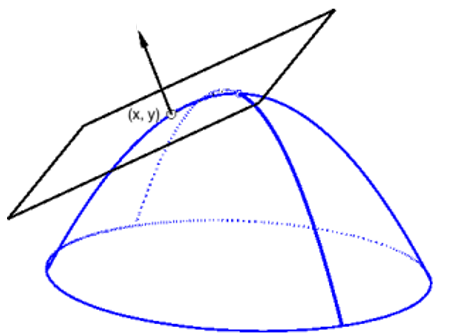

We can further generalize this principle to N dimensions. **The gradient is therefore a generalization of the derivative in N dimensions.**

**Gradient Descent** is an algorithm that uses the gradient to find the smallest possible error when training a machine learning model. How this works exactly will be explained in the following chapters using simple linear regression.

## **2. Simple linear regression**

### What is linear regression?

In **linear regression** we assume a linear relationship between the features of our data and the target to be predicted. The underlying mathematical model is therefore:

> $y_i = a_0 + a_1 x_{i1} + a_2 x_{i2} + ... + a_N x_{i,N}$

with $x_1$, $x_2$, ..., $x_N$ the $N$ **features** and $y$ the **target**. Subscript $i$ refers to the $i$-th **data point**. The coefficients $a_0$, $a_1$, $a_2$, ..., $a_N$ are the **parameters**. It is these $N+1$ parameters that we have to derive based on a given dataset. So in fact linear regression is nothing more than making predictions by taking a **weighted sum** of all features.

Suppose we have a dataset in Excel, then the columns are the features. Making a prediction using linear regression would mean that we first multiply each column by a weight, and then add all the converted columns together.

To keep things simple here, we start with one feature. We call this simple linear regression. This is linear regression applied to a dataset with one independent variable $x$ and one dependent variable $y$. In this case, we are looking for the best fitting line to predict **target** $y$ based on **feature** $x$. This **prediction** or prediction is often referred to as $\hat{y}$, so $y$ with a 'hat' on top.

When we apply linear regression, we assume that there is a linear relationship between variables $x$ and $y$. In other words, the **regression model** consists of a straight line of the following equation:

> $y_i = ax_i + b$

where $a$ is the *slope* (or rico for short), and $b$ is the *intercept*, as we explained above. Subscript $i$ refers to the $i$-th data point $(x_i, y_i)$ in our dataset. Note that in the general model with $N$ features, intercept $b$ is denoted by $a_0$.

We call $a$ and $b$ the **parameters** or weights of the model. When those parameters are known, we know the model, and then we can make predictions. In the figure below, this comes down to the "classical" programming of code, where we get the rules and the data as input, and we give answers as output. In this case, the data is $x_i$ and the model consists of one rule, namely multiply $x_i$ by $a$ and add $b$ to get output $y_i$.

Compare it to making a cocktail. The data are the ingredients you need to make the cocktail; the model or the rules are the recipe that explains step by step how to make the cocktail. The output is of course the cocktail you get when you process the ingredients correctly according to the recipe.

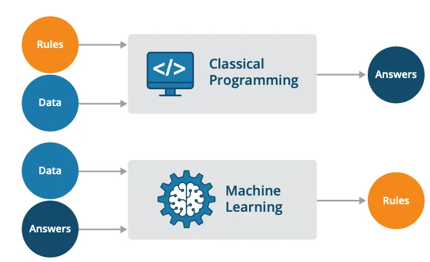

Machine learning boils down to finding the recipe for the cocktail: you know the ingredients, you get the cocktails, but you have to try to estimate the exact quantities. If we return to our regression model, we do not know the parameters $a$ and $b$ in a machine learning problem. We therefore have to derive these parameters based on our dataset.

As the figure above shows, the input therefore consists of data and answers, and by applying a machine learning algorithm to these data and answers, we get the rules or the model as output. In concrete terms, we have to find the parameters $a$ and $b$, and we do this by **training** a model. Once we have found the "best" values ​​for these parameters, we can apply the model to make predictions based on new data, as in "classical" programming. We call this **inference**.

How this "training" is done, and more specifically, how the "best" parameters are derived, is explained in this notebook. There are several possible algorithms, also in linear regression. We will briefly discuss the exact solution method, and then we will go into detail about Gradient Descent, which is a real learning algorithm.

### Example

Let us take the simple dataset from the book where the independent variable $x$ is the number of rooms in a house, and the dependent variable $y$ is the price of a house:

In [ ]:
import pandas as pd

dataset = pd.DataFrame(dict(
    x=[1, 2, 3, 5, 6, 7],             # number of rooms
    y=[155, 197, 244, 356, 407, 448]  # price
))

dataset

,x,y
0,1,155
1,2,197
2,3,244
3,5,356
4,6,407
5,7,448


There are 6 data points or **examples** $(x_i, y_i)$ in our dataset: (1, 155), (2, 197), (3, 244), (5, 356), (6, 407) and (7, 448).

If we plot those points, we see that there is indeed a linear relationship, because the points form a line:

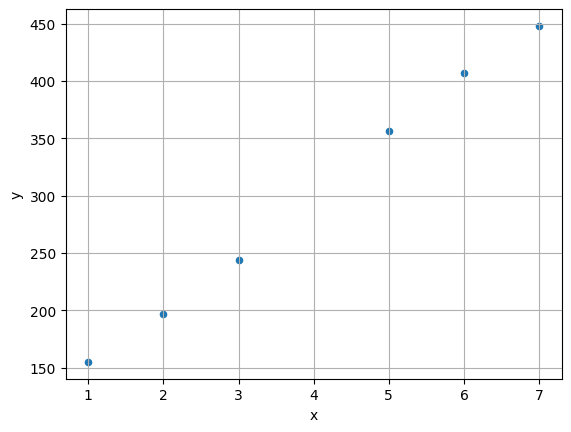

In [ ]:
dataset.plot.scatter(x='x', y='y', grid=True);

But that relationship is usually not 'perfect', as in this example: the points do not lie 'exactly' on a line. So we actually need to add an **error** or deviation to our model:

> $y_i = ax_i + b + \epsilon_i$

where $\epsilon_i$ is the error or deviation for the $i$-th data point $(x_i, y_i)$.

If we make a prediction or **prediction** for the $i$-th data point, we calculate $\hat{y}_i$ as follows:

> $\hat{y}_i = ax_i + b$

From the two equations above, it now follows that the difference between the 'true' value $y$, and the prediction $\hat{y}$ of the corresponding point on the line, is equal to the error $\epsilon$:

> $\epsilon_i = y_i - \hat{y}_i$

Error $\epsilon$ is also called the **residual**.

Suppose we take $a = 50$ and $b = 100$ in our example, then we calculate the predictions as follows:

> $\hat{y}_i = 50x_i + 100$

We add those predictions to the data frame and use `'yp'` as the variable name for $\hat{y}$. We also calculate the deviation.

In [ ]:
dataset['yp'] = 50 * dataset.x + 100 # predictions
dataset['epsilon'] = dataset.y - dataset.yp # deviations
dataset

,x,y,yp,epsilon
0,1,155,150,5
1,2,197,200,-3
2,3,244,250,-6
3,5,356,350,6
4,6,407,400,7
5,7,448,450,-2


Let's also plot the regression line on the graph, i.e. the line on which the predictions lie:

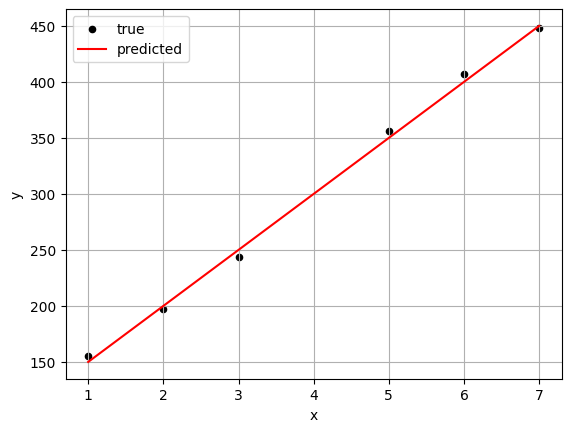

In [ ]:
fig, ax = plt.subplots()
dataset.plot.scatter(x='x', y='y', color='k', ax=ax);
dataset.plot(x='x', y='yp', linestyle='-', color='r', ax=ax);
plt.legend(['true', 'predicted']);
plt.grid();

A common misinterpretation is to explain a linear relationship as a causal relationship, i.e. a relationship of cause and effect, where the independent variable is seen as the cause of the dependent variable. In our example, this would mean that the price of a house is the result of the number of rooms. That could be the case, but that is not what our model says. It only says that there is a linear relationship between the number of rooms and the price of a house. **Linear regression therefore does NOT express a causal relationship!**

### Least squares

We have now given a straight line 'by sight', but in principle the aim is to find the 'best fitting' straight line. This is the straight line where the errors $\epsilon_i$ are as small as possible.

In theory we can solve this problem exactly with the **least squares method**, in English **the method of least squares**. 'Exact' here means that there is a formula to calculate parameters $a$ and $b$ for a given dataset:

> $a = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$

> $b = \bar{y} - a \bar{x}$

where $n$ is the total number of data points, $\bar{x}$ is the average of all $x_i$, and $\bar{y}$ is the average of all $y_i$.

If we apply these formulas to our dataset, we find the following values ​​for parameters $a$ and $b$:

In [ ]:
xm = dataset.x.mean() # mean of x
ym = dataset.y.mean() # mean of y

a = ((dataset.x - xm) * (dataset.y - ym)).sum() / ((dataset.x - xm) ** 2).sum()
b = ym - a * xm

print(f"intercept b = {b:.3f} and rico a = {a:.3f}")

intercept b = 99.595 and rico a = 50.393


With our first estimate we were close to the 'best fit' line, but because we still didn't get it completely right, we recalculate the predictions and the associated deviations:

In [ ]:
dataset['yp'] = a * dataset.x + b            # "best" predictions
dataset['epsilon'] = dataset.y - dataset.yp  # deviations
dataset

,x,y,yp,epsilon
0,1,155,149.988095,5.011905
1,2,197,200.380952,-3.380952
2,3,244,250.773810,-6.773810
3,5,356,351.559524,4.440476
4,6,407,401.952381,5.047619
5,7,448,452.345238,-4.345238


On the graph we will not see any difference from our previous figure, but we will also update the graph by plotting this best-fitting line:

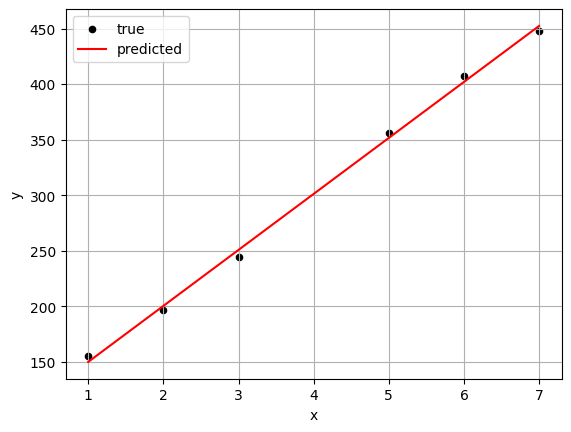

In [ ]:
fig, ax = plt.subplots()
dataset.plot.scatter(x='x', y='y', color='k', ax=ax);
dataset.plot(x='x', y='yp', linestyle='-', color='r', ax=ax);
plt.legend(['true', 'predicted']);
plt.grid();

### Error function

Now, how can we know how "good" our model is? Or in other words, how "close" our line is to the data points? To know that, we need to get an idea of ​​the error of the model. For that, we use an error or **loss function**.

Actually, we want to know the total error, so we could calculate the sum of all deviations $\epsilon_i$:

> $L = \sum_{i=1}^{n}\epsilon_i = \sum_{i=1}^{n} (y_i - \hat{y}_i)$

where $L$ is the loss function that should give an idea of ​​the total error of our regression model.

In [ ]:
print(f"The total error is {dataset.epsilon.sum():.5f}")

The total error is -0.00000


The average deviation is indeed zero, because we derived the parameters $a$ and $b$ under that condition, but the total error is of course not zero. The problem is that positive and negative deviations cancel each other out. So in fact we have to take the absolute value of the deviations. The total error is then the **sum of the absolute values ​​of the deviations**:

> $L = \sum_{i=1}^{n} |\epsilon_i| = \sum_{i=1}^{n} |y_i - \hat{y}_i|$

In [ ]:
print(f"The total error is {dataset.epsilon.abs().sum() :.5f}")

The total error is 29.00000


That does indeed give us a correct idea of ​​the total error. It is also interesting to calculate the mean absolute error by dividing this sum by the number of data points:

> $L = \frac{1}{n}\sum_{i=1}^{n} |\epsilon_i| = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$

This is called the **mean absolute error** (MAE).

In [ ]:
print(f"The MAE is {dataset.epsilon.abs().sum() / dataset.shape[0] :.5f}")

The MAE is 4.83333


Of course, we can code this more simply by using the `mean` method:

In [ ]:
MAE = dataset.epsilon.abs().mean()
print(f"The MAE is {MAE:.5f}")

The MAE is 4.83333


The problem with the absolute value is that the derivative of that function is not so simple. That is why one prefers to take the square of the deviations, which also ensures that all deviations become positive. This loss function is called the **sum of squared errors** (SSE):

> $L = \sum_{i=1}^{n} \epsilon_i^2 = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

In [ ]:
SSE = np.square(dataset.epsilon).sum()
print(f"The SSE is {SSE:.5f}")

The SSE is 146.51190


And here again we can take the average instead of the sum, which is then the **mean squared error** (MSE):

> $L = \frac{1}{n}\sum_{i=1}^{n} \epsilon_i^2 = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

In [ ]:
MSE = np.square(dataset.epsilon).mean()
print(f"The MSE is {MSE:.5f}")

The MSE is 24.41865


By squaring the deviations, the MSE no longer has the same unit as the target. In our example, we are talking about house prices expressed in 1000 euros. By squaring the deviations, the MSE gets a unit of 1,000,000 square euros, which is difficult for us to interpret. That is why people often take the square root of the MSE so that the error is expressed in the same unit as the target. We call this metric the **root mean square error** (RMSE):

In [ ]:
RMSE = np.sqrt(np.square(dataset.epsilon).mean())  # sqrt(MSE)
print(f"The RMSE is {RMSE:.5f}")

The RMSE is 4.94152


Another commonly used metric in simple linear regression is the **coefficient of determination $R^2$**. The $R^2$ score is a number between 0 and 1, and the closer it is to 1, the better the model fit the data set. Simply put, $R^2$ tells you what percentage of the data is explained by the regression model. (It's actually about the percentage of variance, but that would take us too far here.)

The exact definition of $R^2$ is:

> $R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} = 1 - \frac{SSE}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$

where $\bar{y}$ is the average of all labels $y_i$. Applying that formula, we get:

In [ ]:
R2 = 1 - (dataset.epsilon**2).sum() / np.square(dataset.y - ym).sum()
print(f"Coefficient of determination R² is {R2:.5f}")

Coefficient of determination R² is 0.99794


As expected, the R² of our regression model is very close to 1 because it is a very good fit.

Finally, we also mention here another frequently used coefficient, the **Pearson correlation coefficient $R$**. In simple linear regression, it is the square root of the determination coefficient $R^2$. And you immediately know why the latter is written this way.

As you know, this square root can be either positive or negative. But which one should you choose? Well, if the line is increasing, then $R$ is positive, otherwise you take the negative one. Here we have an increasing line, and so $R$ is positive:

In [ ]:
print(f"Correlation coefficient R is {np.sqrt(R2):.5f}")

Correlation coefficient R is 0.99897


As the name suggests, the correlation coefficient expresses the degree to which two variables are correlated, and in simple linear regression it is therefore a measure of the linear relationship between the independent and dependent variables. It is a number between -1 and 1, and we can interpret the absolute value of $R$ as follows:

- |R| = 0: no linear relationship
- 0 < |R| < 0.2: hardly any linear relationship
- 0.2 < |R| < 0.4: weak linear relationship
- 0.4 < |R| < 0.6: reasonably linear relationship
- 0.6 < |R| < 0.8: strong linear relationship
- 0.8 < |R| < 1: very strong linear relationship
- |R| = 1: perfect linear relationship

In everyday computer science, we are mainly interested in absolute values ​​for $R$ greater than 0.6.

We have already pointed out that a correlation does not reveal a causal relationship. **Also note that the absence of a linear relationship does not mean that there is no relationship!** We see this nicely in the figure below: you see various scatter plots with the value for the correlation coefficient above them. The lower datasets all have an $R$ value equal to zero, because there is indeed no linear relationship, but clearly another relationship!

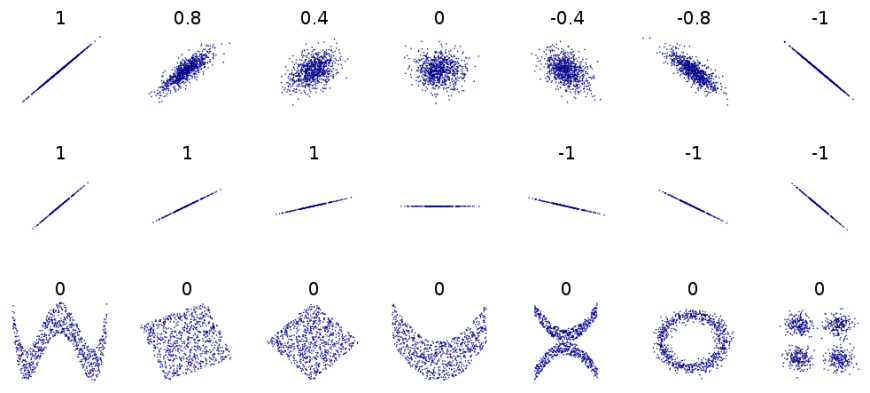

## **3. Gradient Descent**

Most of the problems we're going to solve with machine learning are not nearly as simple as simple linear regression. Usually we have many more features, so the problem is no longer two-dimensional but N-dimensional. And often the problem is not linear either. In that case we need an iterative **learning algorithm**, because that "learning" is of course what machine learning is all about. **Gradient Descent** is such an algorithm, and it's called an **optimizer** as it tries to find the optimal values for the model parameters.

In supervised learning, the goal is to make the deviation between labels and predictions as small as possible. In mathematical jargon, it is said that one should **minimize** the **loss function**. We can compare this loss function to a mountain landscape in which we want to find the deepest valley, because that valley corresponds to the smallest total error.

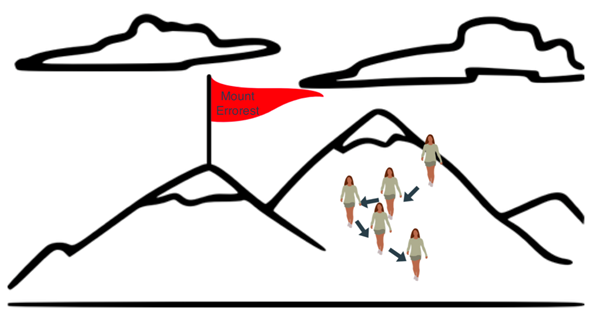

### Minimizing the loss function

In the case of simple linear regression, we have 2 parameters and so we can still represent "the mountain landscape" in a 3D coordinate system. How do we do that? Well, we calculate the loss function for a range of values ​​for slope $a$ and intercept $b$. We determine that range using the NumPy function `linspace`. If we take the SSE as loss function $L$, our code looks like this:

In [ ]:
a_range = np.linspace(40, 60, 100) # 100 values ​​for a between 40 and 60
b_range = np.linspace(50, 150, 100) # 100 values ​​for b between 50 and 150

SSE = np.zeros((len(a_range), len(b_range))) # initialize array containing SSE for all combinations of a and b

for irow, b in enumerate(b_range):
    for icol, a in enumerate(a_range):
        yp = a * dataset.x + b # predictions
        SSE[irow, icol] = ((dataset.y - yp)**2).sum() # loss function SSE

We now create a **contour plot** of the loss function. A contour plot can be seen as a projection of a 3D surface onto a horizontal plane, where the points that have the same height are connected to each other. In our example, the contour plot connects the points with the same value for the SSE. These are called the **contour lines**. Compare it to a map on which height lines are indicated.

In our example, the contour lines are elliptical. To show more clearly that our loss function effectively has a minimum, we take the logarithm of the SSE. The surface of the loss function therefore indeed contains a "well" and that is the point where the SSE is minimum. We see that at this point $a$ is approximately 50 and $b$ is approximately 100. The exact minimum that we calculated above is indicated as a red dot.

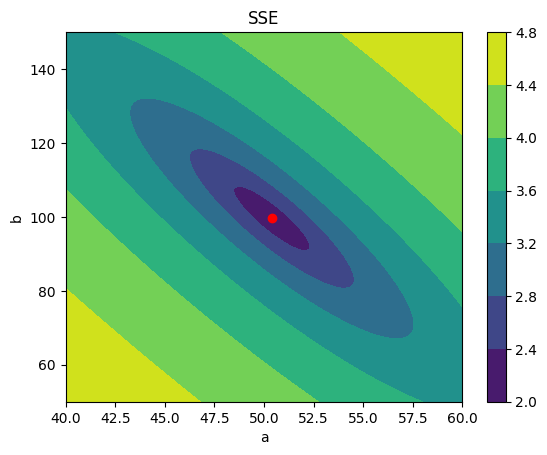

In [ ]:
plt.contourf(a_range, b_range, np.log10(SSE)); # contour plot of the logarithm of the SSE
plt.plot(50.393, 99.595, 'ro'); # plot exact minimum
plt.xlabel('a');
plt.ylabel('b');
plt.title('SSE');
plt.colorbar();

Based on all these calculations we can now determine the point $(a, b)$ with the smallest value for the SSE:

In [ ]:
irow, icol = np.unravel_index(np.argmin(SSE), SSE.shape)
print(f"({a_range[icol]:.4f}, {b_range[irow]:.4f})")

(50.5051, 99.4949)


We are indeed very close! However, such a brute-force approach is not at all practical and even impossible when we are dealing with a lot of data that contains a lot of features that we want to fit with a model with a lot of parameters. So we are going to have to apply a more intelligent algorithm, and that algorithm is called **Gradient Descent**.

We start with a random point on the mountain landscape. In our case, we are going to determine a random value for parameters $a$ and $b$. At that point, we look for the direction where the slope goes down the steepest, and we take a small step in that direction. There, we look again where the slope goes down the steepest and we take another step down in that direction. And we repeat this as often as necessary until we have reached the deepest valley in the mountain landscape. At that point, we find the optimal values ​​for $a$ and $b$, and in our case that corresponds to the best fitting line. Or in other words, to the model that gives the predictions with the smallest deviations on average.

Suppose we already know one of the two parameters, namely intercept $b$. In that case our problem becomes one-dimensional, because we have only one unknown parameter left. We recompute the SSE for a range of values ​​for $a$:

In [ ]:
a_range = np.linspace(40, 60, 100)  # 100 values ​​for a between 40 and 60
b_opt = 99.595  # we already know the optimal value of b

SSE = np.zeros(len(a_range))  # initialize vector with SSE for values ​​of a

for i, a in enumerate(a_range):
    yp = a * dataset.x + b_opt  # predictions
    SSE[i] = ((dataset.y - yp)**2).sum()  # loss function SSE

In this way we make a vertical 2D section through our mountain landscape at the height of $b = 99.595$. In this case our mountain landscape is reduced to a curve with a pit that we can draw in a 2D coordinate system:

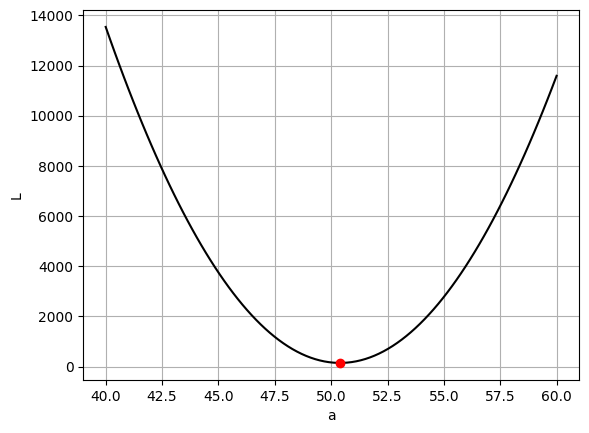

In [ ]:
plt.plot(a_range, SSE, 'k-');
yp = a * dataset.x + b  # predictions
a_opt = 50.393  # the optimal value for a
SSE_min = ((dataset.y - (a_opt * dataset.x + b_opt))**2).sum()  # the minimum SSE
plt.plot(a_opt, SSE_min, 'ro');  # plot exact minimum
plt.xlabel('a');
plt.ylabel('L');  # L is the loss function which is the SSE here
plt.grid();

### The gradient

In two dimensions, the gradient of a curve is the derivative of the function that describes that curve. The derivative at a point on that curve is actually the slope of the tangent to the curve at that point. We discussed that extensively in the first chapter.

We will therefore estimate the slope of the curve at a certain point on that curve based on the derivative of the loss function with respect to parameter $a$, which we denote as $\frac{\delta L}{\delta a}$. In this version of Gradient Descent, we will calculate that derivative based on an arbitrary data point $i$. To calculate the derivative, we need to apply the chain rule:

> $\frac{\delta L}{\delta a} = 2 (y_i - \hat{y}_i) (-x_i)$

The tangent line is now a line whose slope or slant we can calculate and of course we also know the point $(L_0, a_0)$ that lies on that line. If we know the slant and one point of a line, we can write the equation of that line. In this case:

> $L = L_0 + \frac{\delta L}{\delta a}(a-a_0)$

Subscript $0$ in this case refers to the initial values ​​of $a$ and $L$.

Let's demonstrate this with a simple example. Let's take the 3rd data point in the dataset, i.e. (3, 244). In order to nicely illustrate the concept of the tangent line, we will restrict our dataset to that one point. This means that our loss function $L$ is the squared error of that point for all possible values ​​of $a$ (because we still set $b$ equal to the optimal value):

In [ ]:
a_range = np.linspace(40, 56, 100)  # let slope a vary between 40 and 56
i = 2  # third data point
x, y = dataset.x[i], dataset.y[i]
L = (y - (a_range * x + b_opt)) ** 2  # squared error

Of course, in the case of 1 data point, we can obtain a perfect fit:

> $y_i = ax_i + b$

Since $b$ is known, it follows from this equation that:

> $a = \frac{y_i - b}{x_i}$

The optimal value for $a$ is no longer equal to 50.4 when we restrict the data set to the third point:

In [ ]:
print((y - b_opt) / x)

48.135


The associated minimum error is of course equal to 0 here, because we can fit one point perfectly. But to demonstrate the Gradient Descent algorithm, we will solve the problem iteratively. We start at a random point, here e.g. $a_0 = 45$. The loss function $L_0$ is the squared error of the third data point, calculated with $a_0$:

In [ ]:
a0 = 45
L0 = (y - (a0 * x + b_opt))**2  # squared error
print(f"(a0, L0) = ({a0:.1f},{L0:.1f})")

(a0, L0) = (45.0,88.5)


We now calculate the derivative at the point (45.0, 88.5):

In [ ]:
delta = -2 * (y - (a0 * x + b_opt)) * x  # derivative of L with respect to a at a0
print('slope of the tangent is:', delta)

slope of the tangent is: -56.43000000000001


The equation of the tangent line is therefore:

> $L = 88.5 - 56.43 (a - 45)$

We now draw the tangent line from $a=42$ to $a=48$, so that our point $(a_0, L_0)$ lies nicely in the middle:

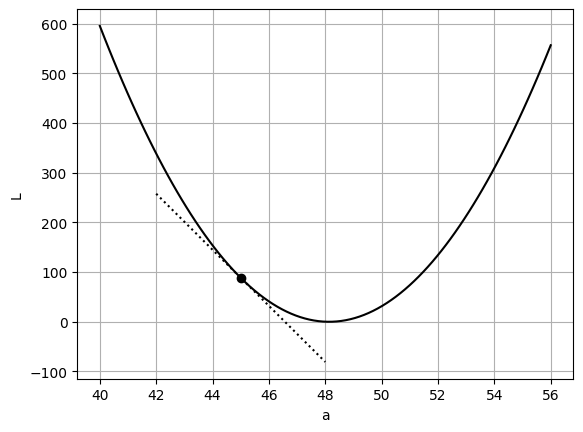

In [ ]:
plt.plot(a_range, L, 'k-');
plt.xlabel('a');
plt.ylabel('L');  # L is the loss function which is the SSE here

# tangent
a_tangent = np.array([42, 48])
L_tangent = L0 + delta * (a_tangent - a0)
plt.plot(a0, L0, 'ko');
plt.plot(a_tangent, L_tangent, 'k:');
plt.grid();

We now adjust the parameter $a_0$ by subtracting a small fraction of the slope of the tangent line:

> $a_1 = a_0 - \alpha \frac{\delta L}{\delta a}$

where $\alpha$ is the **learning rate** with which we can control the size of our steps. Suppose we take that learning rate here equal to 0.025, then $a_1$ becomes:

In [ ]:
alpha = 0.025
a1 = a0 - alpha * delta
print(f"a1 = {a1}")

a1 = 46.41075


We see that the new value for $a$ does indeed become larger and thus moves towards the minimum. The error therefore also becomes smaller, as does the derivative, because the curve becomes less steep as we get closer to the minimum:

In [ ]:
# Calculate L1 and derivative delta
L1 = (y - (a1 * x + b_opt)) ** 2 # squared error
print(f"(a1, L1) = ({a1:.1f}, {L1:.1f})")
delta = -2 * (y - (a1 * x + b_opt)) * x # derivative of L with respect to a in a1
print('slope of the tangent line is:', delta)

(a1, L1) = (46.4, 26.8)
slope of the tangent line is: -31.036500000000046


We visualize all this by plotting the loss function again with the new point $(a_1, L_1)$ marked on it and the tangent line at that point:

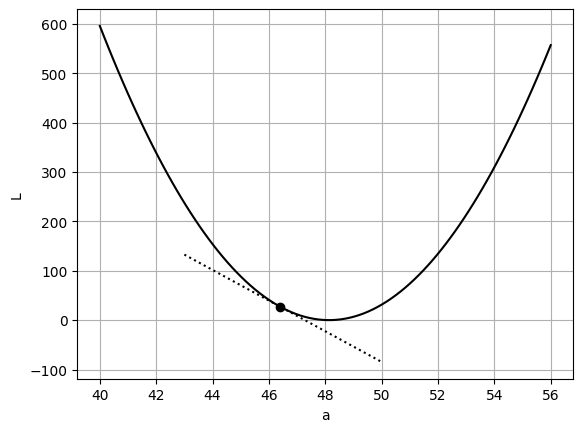

In [ ]:
# plot of a vs L
plt.plot(a_range, L, 'k-');
plt.xlabel('a');
plt.ylabel('L'); # L is the loss function which is the SSE here
plt.grid();

# tangent
a_tangent = np.array([43, 50])
L_tangent = L1 + delta * (a_tangent - a1)
plt.plot(a1, L1, 'ko');
plt.plot(a_tangent, L_tangent, 'k:');

Indeed, we see that the tangent line becomes flatter. In the minimum of the function, the tangent line is even perfectly horizontal, and so the derivative is zero there. In this simple example with 1 parameter and 1 data point, we can directly determine the minimum by setting the derivative equal to zero:

> $\frac{\delta L}{\delta a} = 2 (y_i - \hat{y}_i) (-x_i) = 0$

from which it follows that:

> $a_{opt} = \frac{y_i - b_{opt}}{x_i}$

That is indeed the solution we derived earlier:

In [ ]:
a_opt = (y - b_opt) / x
print(a_opt)

48.135


Finally, let's also plot the graph for this optimal value:

(a_opt, L_min) = (48.1, 0.0)
slope of the tangent in the minimum is: -0.0


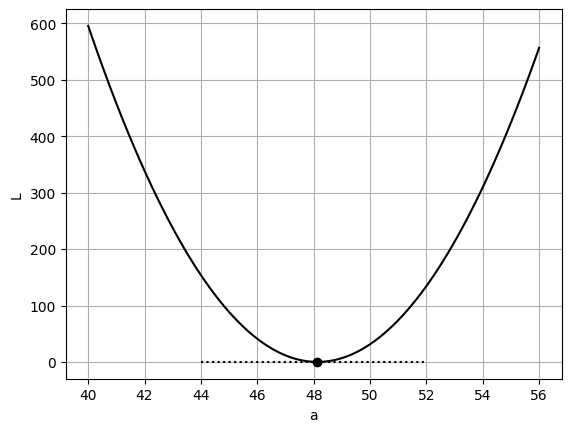

In [ ]:
# Calculate L and derivative delta in the minimum
L_opt = (y - (a_opt * x + b_opt))**2
print(f"(a_opt, L_min) = ({a_opt:.1f}, {L_opt:.1f})")
delta = -2 * (y - (a_opt * x + b_opt)) * x
print('slope of the tangent in the minimum is:', delta)

# plot of a vs L
plt.plot(a_range, L, 'k-');
plt.xlabel('a');
plt.ylabel('L'); # L is the loss function which is the SSE here
plt.grid();

# tangent
a_tangent = np.array([44, 52])
L_tangent = L_opt + delta * (a_tangent - a_opt)
plt.plot(a_opt, L_opt, 'ko');
plt.plot(a_tangent, L_tangent, 'k:');

Indeed, we see that the tangent is perfectly horizontal.

This example also clearly shows the role of the learning rate. If we make it very small, then we take very small steps and then it will take a long time before we reach the minimum, perhaps even too long. But we should not make the learning rate too large either, because if we take too large steps, then we pass the minimum, which we call **overshooting**, and so we get further and further away from the minimum. Let us start again at $a=45$, but this time we take the learning rate equal to 1:

In [ ]:
alpha = 1
delta = -2 * (y - (a0 * x + b_opt)) * x
a1 = a0 - alpha * delta
print(f"a1 = {a1}")

a1 = 101.43


We are indeed "shooting" far beyond the minimum here... We say that in this case the algorithm **diverges**. When the algorithm does come closer and closer to the minimum, we speak of **convergence**.

### The algorithm

In the example we have actually already demonstrated the algorithm for optimizing parameter $a$ (where we have kept parameter $b$ constant) based on 1 data point (where we have ignored the other data points). We can of course continue to optimize parameter $b$ in the same way. Only the partial derivative is a bit different:

> $\frac{\delta L}{\delta b} = 2 (y_i - \hat{y}_i) (-1)$

If we want to take all data points into account, we will still approximate the gradient using 1 data point, but we will go through all data points in succession. The order in which we go through the data points is arbitrary, and when we have gone through them all once, we call that an **epoch**. In order to find the minimum, we usually have to perform many epochs.

Parameters $a$ and $b$ must therefore be adjusted at the end of each iteration as follows:

> $a_{new} = a - \alpha \frac{\delta L}{\delta a} = a + \alpha (y_i - \hat{y}_i)x_i$

> $b_{new} = b - \alpha \frac{\delta L}{\delta b} = b + \alpha (y_i - \hat{y}_i)$

We see that the constant equal to 2 in the expression of the derivatives is included in the learning rate. That is okay because the learning rate is also a constant. To keep it mathematically correct, the SSE is sometimes also divided by 2 when defining the loss function.

The **Gradient Descent algorithm** works as follows:

Given:
- a dataset with $n$ data points $(x_i, y_i)$
- the number of epochs $n_{epochs}$
- the learning rate $\alpha$

Steps:

0. Initialize parameters $a$ and $b$ with random values

1. Repeat $n_{epochs}$ times:
  2. Repeat $n$ times:
    3. Select a random data point $(x_i, y_i)$ from the dataset (without replacement!)
    4. Compute the prediction $\hat{y}_i = ax_i + b$
    5. Compute the deviation $\epsilon_i = y_i - \hat{y}_i$, and multiply the deviation by the learning rate: $\delta_i = \alpha \epsilon_i$
    6. Adjust parameters $a$ and $b$ on by means of the deviation:
        - $a_{new} = a + \alpha (y_i - \hat{y}_i) x_i = a + \delta_i x_i$
        - $b_{new} = b + \alpha (y_i - \hat{y}_i) = b + \delta_i$

We implement the algorithm in a function. It is also common to calculate and maintain the loss function after each epoch. We take the SSE as loss function:

In [ ]:
from random import shuffle

def gradient_descent(x, y, n_epochs, alpha):
    """
    Gradient Descent algorithm for simple linear regression

    Input parameters:
    - x: array with values ​​of the independent variable or the feature (length is n)
    - y: array with values ​​of the dependent variable or the target (length is n)
    - n_epochs: integer that determines the number of epochs
    - alpha: float that determines the learning rate

    Return values:
    - a: array with the slope derived after each iteration (length is n_epochs * n)
    - b: array with the intercept derived after each iteration (length is n_epochs * n)
    - L: array with SSE calculated after each epoch (length is n_epochs)
    The optimal values ​​for slope and intercept are therefore a[-1] and b[-1],
    and the corresponding SSE is L[-1]
    """

    # initialize
    a, b = np.random.rand(), np.random.rand()
    a_path, b_path = [], [] # we are going to keep track of all values ​​of a and b
    L = [] # loss function
    idx = list(range(len(x))) # indices of the data points

    # outer loop: epochs
    for _ in range(n_epochs):

        shuffle(idx) # shuffle indices

        # inner loop: randomize data points
        for i in idx:

            yp = a * x[i] + b  # prediction
            delta = alpha * (y[i] - yp)  # learning rate times deviation

            a += delta * x[i]  # adjust slope
            b += delta  # adjust intercept

            a_path.append(a)
            b_path.append(b)

            # loss function: SSE
            L.append(np.sum((y - (a * x + b)) ** 2))

    # output
    return np.array(a_path), np.array(b_path), np.array(L)

Note that we also keep track of all the intermediate values ​​of $a$ and $b$. This way we can start drawing the trajectory that the Gradient Descent algorithm follows on the contour plot.

Now let's test the algorithm on our dataset:

In [ ]:
x, y = dataset.x.values, dataset.y.values
a_path, b_path, loss = gradient_descent(x, y, n_epochs=500, alpha=0.01)
print(a_path[-1], b_path[-1])

50.4372727196759 99.64189614000814


We come very close to the correct minimum that we just calculated exactly using the least squares method. We do notice that we have to take enough epochs. The parameters $n_{epochs}$ and $\alpha$ are called **hyperparameters**, because they are not derived by the algorithm, but are specified by the user.

Let's also look at the progression of the loss function:

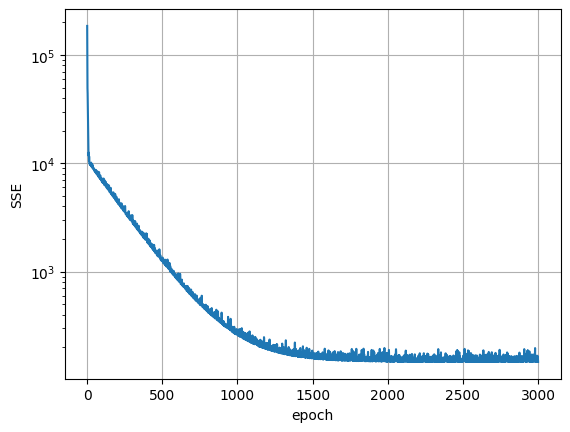

In [ ]:
plt.semilogy(np.arange(1, len(loss)+1), loss);
plt.xlabel('epoch');
plt.ylabel('SSE');
plt.grid();

Of course the loss function never becomes zero, but after a large number of epochs we no longer see much improvement.

Finally, we create the contour plot again, and this time we add to it the path that Gradient Descent has taken from the initial values ​​for $a$ and $b$ to the minimum:

In [ ]:
a_range = np.linspace(0, 100, 100)
b_range = np.linspace(0, 200, 100)
SSE = np.zeros((len(a_range), len(b_range))) # matrix with SSE for all combinations of a and b
for irow, b in enumerate(b_range):
    for icol, a in enumerate(a_range):
        yp = a * dataset.x + b # predictions
        SSE[irow, icol] = ((dataset.y - yp) **2).sum() # loss function SSE

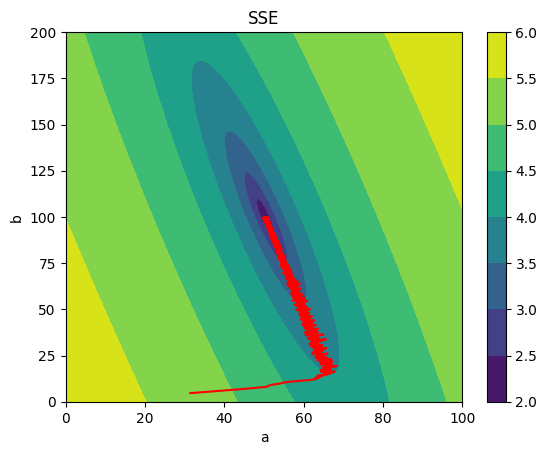

In [ ]:
plt.contourf(a_range, b_range, np.log10(SSE)); # contour plot of the logarithm of the SSE
plt.xlabel('a');
plt.ylabel('b');
plt.title('SSE');
plt.colorbar();
plt.plot(a_path, b_path, 'r-'); # plot the path of Gradient Descent
plt.xlim(a_range[[0, -1]]);
plt.ylim(b_range[[0, -1]]);

The algorithm starts at the bottom left at a random point $(a_0, b_0)$ and indeed goes down the slope step by step towards the minimum. When descending, the algorithm zigzags because we do not calculate the gradient exactly, but approximate it each time based on only 1 data point.

In the algorithm, we have initialized the parameters $a$ and $b$ randomly. We have also randomly traversed the data points. That is why we call this algorithm **Stochastic Gradient Descent** (SGD). Stochastic means that the algorithm contains elements of randomness, which is effectively the case here.

We can also determine the gradient based on all points in the dataset. In this case, we call it **(Full) Batch Gradient Descent**. This algorithm has the advantage that it is often faster and more stable, but it must be able to hold the entire dataset in RAM memory, which is not possible with large datasets. A compromise between the two is to work with so-called mini-batches: the gradient is determined based on a few data points that are also randomly grouped. This algorithm is called **Mini-Batch Gradient Descent**. The size of such a batch is constant. This **batch size** is also a hyperparameter that is specified by the user. Usually one takes a power of two, e.g. 32.

## **4. Scikit Learn**

Linear regression is built into Scikit Learn:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

First we need to import the class `LinearRegression` from the module `linear_model`. Note that Scikit Learn itself needs to be imported as `sklearn`.

Then we instantiate the class `LinearRegression` and call the `fit` method of the created object, passing the `x` and `y` values ​​of our dataset. Note! The method can also handle multiple features and therefore the input argument `X` needs to be a 2D matrix. That is why we add an extra 'axis' to `x` using `np.newaxis`:

In [ ]:
from sklearn.linear_model import LinearRegression

x, y = dataset.x.values, dataset.y.values

lr = LinearRegression()
lr.fit(x[:, np.newaxis], y)

LinearRegression()

Note that we do not need to pass the learning rate or the number of epochs to the `fit` method because that method uses the Ordinary Least Squares (OLS) method.

The derived parameters can be found in attributes `coef_`, which is the ricochet, and `intercept_`:

In [ ]:
print(f"slope = {lr.coef_[0] :.2f}, intercept = {lr.intercept_ :.2f}")

slope = 50.39, intercept = 99.60


Attribute `coef_` is an array, because in general we derive $N$ coefficients if there are $N$ features. In linear regression we indeed have $N+1$ parameters if there are $N$ features. Here we only have 1 feature, so we only get 1 coefficient, the rico. But in total we have 2 parameters: rico and intercept.

Suppose there are 2 features $x_1$ and $x_2$ and 1 label $y$, then we fit the data using a 2D plane with the general equation:

> $y = a_0 + a_1x_1 + a_2x_2$

The intercept here is $a_0$ and in this case there are two coefficients $a_1$ and $a_2$. In total we indeed have 3 parameters that need to be optimized.

We can therefore also generalize to $N$ features. As we have already seen, we then get the following equation:

> $y = a_0 + a_1 x_{1} + a_2 x_{2} + ... + a_N x_{N}$

This is the equation of a hyperplane in $N+1$ dimensions with the same number of parameters. We can no longer represent that hyperplane graphically, but we can plot 2D or 3D sections through that hyperplane. In the exercises, we will apply linear regression to a dataset with more than 1 feature.

With the method `predict` we can now make predictions, e.g. for a house with 4 rooms:

In [ ]:
lr.predict([[4]])

array([301.16666667])

Here too we need to put $x=4$ in a 2D array, hence the double square brackets.

Finally, there is also a `score` method which gives the coefficient of determination or $R^2$:

In [ ]:
lr.score(x[:, np.newaxis], y)

0.9979437166148433

We had already calculated this score ourselves. Remember that the $R^2$ score is a number between 0 and 1, and the closer to 1, the better the model has fitted the dataset. We also calculate the R² score ourselves with the following formula:

> $R^2 = 1 - \frac{SSE}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$

In [ ]:
yp = lr.predict(x[:, np.newaxis])
SSE = np.square(yp - y).sum()
R2 = 1 - SSE / np.square(y - y.mean()).sum( )
print(f"R² = {R2:.5f}")

R² = 0.99794


Finally, it is also interesting to know that Scikit Learn also provides the functions `mean_absolute_error`, `mean_squared_error`, and `r2_score` to calculate the MAE, the MSE, and the R² score, resp.:

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MAE = mean_absolute_error(y_true=y, y_pred=yp)
MSE = mean_squared_error(y_true=y, y_pred=yp)
R2 = r2_score(y_true=y, y_pred=yp)

print(f"The MAE is {MAE:.5f}")
print(f"The MSE is {MSE:.5f}")
print(f"The R² score is {R2:.5f}")

The MAE is 4.83333
The MSE is 24.41865
The R² score is 0.99794


We get the same values ​​as we calculated ourselves earlier. Note that these functions are part of the Scikit Learn module `sklearn.metrics`, because we also call the MAE, MSE, and R² **evaluation metrics**. After all, they are used to objectively evaluate how well a model performs. The MAE and MSE are widely used evaluation metrics in regression problems. Later in the course we will discuss other evaluation metrics, e.g. for performing classification tasks, where accuracy is a widely used evaluation metric.

---

---
## SOURCES
* Textbook: Grokking Machine Learning (version 12), Manning Early Access Program, by Luis G. Serrano, 2020.
* Chapter "Correlation and regression", Course Data Science I, Professional Bachelor's Degree in Applied Computer Science, Karel de Grote Hogeschool, compiled by K. Demuynck, 2018.
* https://nl.wikipedia.org/wiki/Gradi%C3%ABnt
* https://nl.wikipedia.org/wiki/Gradi%C3%ABnt_(wiskunde)
* https://en.wikipedia.org/wiki/Least_squares
* http://www.personal.psu.edu/sxj937/Notes/Tangent_Planes_and_Linear_Approximations.pdf
*  https://nl.wikipedia.org/wiki/Determinatieco%C3%ABffici%C3%ABnt
* https://nl.wikipedia.org/wiki/Correlationco%C3%ABffici%C3%ABnt
* https://www.knowledgehut.com/blog/data-science/interpret-r-squared-and-goodness-fit-regression-analysis
* https://towardsdatascience.com/batch-mini-batch-stochastic-gradient-descent-7a62ecba642a
* https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
* https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

---